In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = {
    "Order_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "Date": [
        "2026-01-05", "2026-01-07", "2026-01-10", "2026-01-12",
        "2026-01-15", "2026-01-18", "2026-01-20", "2026-01-22",
        "2026-01-25", "2026-01-28"
    ],
    "Product": [
        "Laptop", "Mouse", "Chair", "Keyboard", "Laptop",
        "Monitor", "Mouse", "Desk", "Keyboard", "Laptop"
    ],
    "Category": [
        "Electronics", "Electronics", "Furniture", "Electronics",
        "Electronics", "Electronics", "Electronics", "Furniture",
        "Electronics", "Electronics"
    ],
    "Quantity": [2, 5, 3, 4, 1, 2, 6, 2, 3, 50],
    "Price": [55000, 800, 4500, 1200, 55000, 15000, 800, 7000, 1200, 55000],
    "City": [
        "Chennai", "Bangalore", "Chennai", "Coimbatore",
        "Chennai", "Bangalore", "Chennai", "Madurai",
        "Coimbatore", "Chennai"
    ]
}

df = pd.DataFrame(data)

df

,Order_ID,Date,Product,Category,Quantity,Price,City
0,1001,2026-01-05,Laptop,Electronics,2,55000,Chennai
1,1002,2026-01-07,Mouse,Electronics,5,800,Bangalore
2,1003,2026-01-10,Chair,Furniture,3,4500,Chennai
3,1004,2026-01-12,Keyboard,Electronics,4,1200,Coimbatore
4,1005,2026-01-15,Laptop,Electronics,1,55000,Chennai
5,1006,2026-01-18,Monitor,Electronics,2,15000,Bangalore
6,1007,2026-01-20,Mouse,Electronics,6,800,Chennai
7,1008,2026-01-22,Desk,Furniture,2,7000,Madurai
8,1009,2026-01-25,Keyboard,Electronics,3,1200,Coimbatore
9,1010,2026-01-28,Laptop,Electronics,50,55000,Chennai


In [4]:
df["Sales"] = df["Quantity"] * df["Price"]

df

,Order_ID,Date,Product,Category,Quantity,Price,City,Sales
0,1001,2026-01-05,Laptop,Electronics,2,55000,Chennai,110000
1,1002,2026-01-07,Mouse,Electronics,5,800,Bangalore,4000
2,1003,2026-01-10,Chair,Furniture,3,4500,Chennai,13500
3,1004,2026-01-12,Keyboard,Electronics,4,1200,Coimbatore,4800
4,1005,2026-01-15,Laptop,Electronics,1,55000,Chennai,55000
5,1006,2026-01-18,Monitor,Electronics,2,15000,Bangalore,30000
6,1007,2026-01-20,Mouse,Electronics,6,800,Chennai,4800
7,1008,2026-01-22,Desk,Furniture,2,7000,Madurai,14000
8,1009,2026-01-25,Keyboard,Electronics,3,1200,Coimbatore,3600
9,1010,2026-01-28,Laptop,Electronics,50,55000,Chennai,2750000


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset information:")
df.info()

Missing values:
Order_ID    0
Date        0
Product     0
Category    0
Quantity    0
Price       0
City        0
Sales       0
dtype: int64

Duplicate rows:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  10 non-null     int64 
 1   Date      10 non-null     object
 2   Product   10 non-null     object
 3   Category  10 non-null     object
 4   Quantity  10 non-null     int64 
 5   Price     10 non-null     int64 
 6   City      10 non-null     object
 7   Sales     10 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 772.0+ bytes


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Order_ID             int64
Date        datetime64[ns]
Product             object
Category            object
Quantity             int64
Price                int64
City                object
Sales                int64
dtype: object


In [7]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Quantity"] < lower_limit) |
    (df["Quantity"] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

print("\nOutliers found:")
print(outliers)

Lower limit: -2.125
Upper limit: 8.875

Outliers found:
   Order_ID       Date Product     Category  Quantity  Price     City    Sales
9      1010 2026-01-28  Laptop  Electronics        50  55000  Chennai  2750000


In [8]:
# Remove the identified outlier
df_cleaned = df[df["Quantity"] <= upper_limit].copy()

print("Original rows:", len(df))
print("Rows after removing outlier:", len(df_cleaned))

df_cleaned

Original rows: 10
Rows after removing outlier: 9


,Order_ID,Date,Product,Category,Quantity,Price,City,Sales
0,1001,2026-01-05,Laptop,Electronics,2,55000,Chennai,110000
1,1002,2026-01-07,Mouse,Electronics,5,800,Bangalore,4000
2,1003,2026-01-10,Chair,Furniture,3,4500,Chennai,13500
3,1004,2026-01-12,Keyboard,Electronics,4,1200,Coimbatore,4800
4,1005,2026-01-15,Laptop,Electronics,1,55000,Chennai,55000
5,1006,2026-01-18,Monitor,Electronics,2,15000,Bangalore,30000
6,1007,2026-01-20,Mouse,Electronics,6,800,Chennai,4800
7,1008,2026-01-22,Desk,Furniture,2,7000,Madurai,14000
8,1009,2026-01-25,Keyboard,Electronics,3,1200,Coimbatore,3600


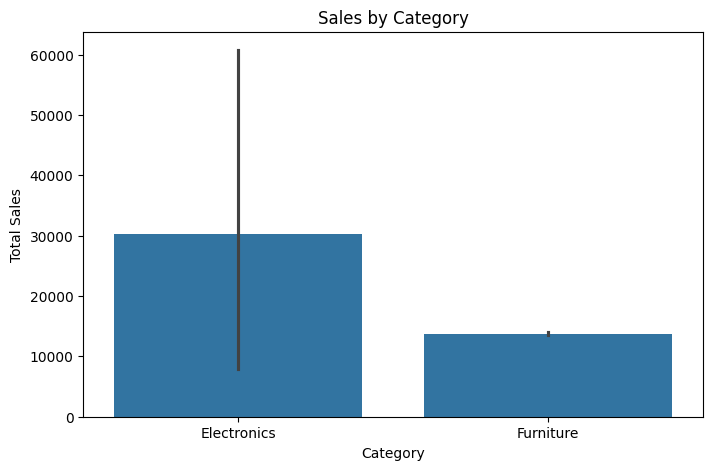

In [9]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df_cleaned, x="Category", y="Sales")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

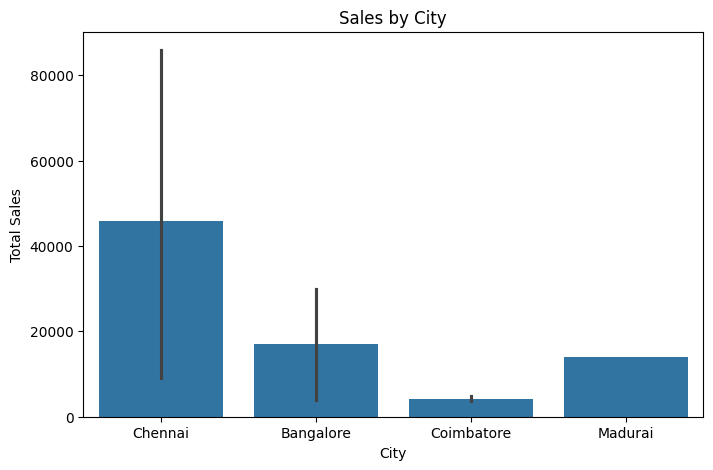

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df_cleaned, x="City", y="Sales")

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

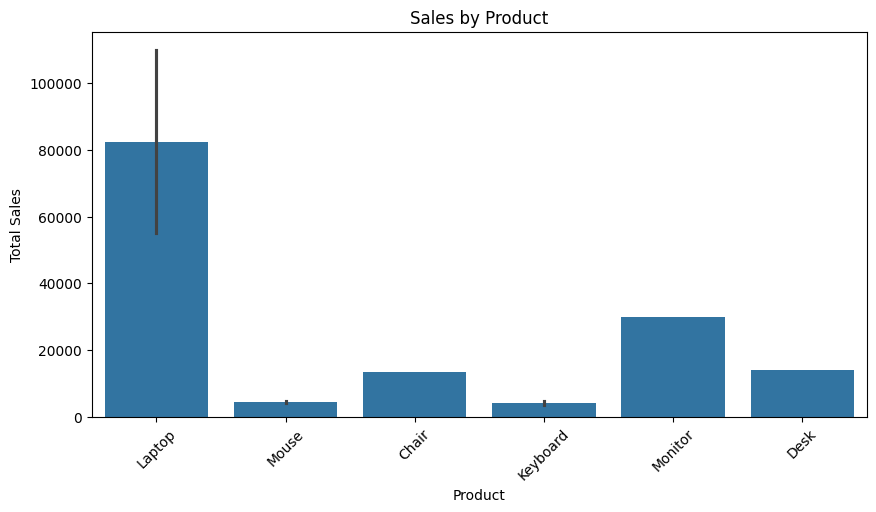

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df_cleaned, x="Product", y="Sales")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

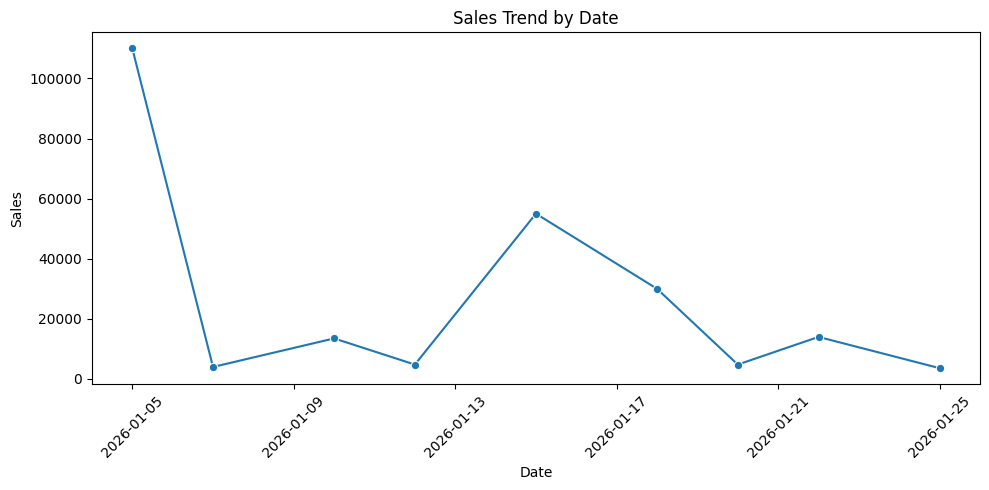

In [12]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=df_cleaned, x="Date", y="Sales", marker="o")

plt.title("Sales Trend by Date")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
print("SALES SUMMARY")
print("----------------------")
print("Total Sales:", df_cleaned["Sales"].sum())
print("Average Sales:", df_cleaned["Sales"].mean())
print("Maximum Sales:", df_cleaned["Sales"].max())
print("Minimum Sales:", df_cleaned["Sales"].min())

SALES SUMMARY
----------------------
Total Sales: 239700
Average Sales: 26633.333333333332
Maximum Sales: 110000
Minimum Sales: 3600


Conclusion

The sales data was successfully analyzed using Python, Pandas, Matplotlib, and Seaborn. The analysis identified sales performance by category, city, and product. The sales trend and summary statistics helped understand the overall business performance. Outliers were also identified and removed to improve the quality of the analysis.